In [2]:

!pip install -q kaggle xgboost shap imbalanced-learn
!kaggle datasets download -d mlg-ulb/creditcardfraud -p ../data

import zipfile
with zipfile.ZipFile('../data/creditcardfraud.zip', 'r') as zip_ref:
    zip_ref.extractall('../data')


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
creditcardfraud.zip: Skipping, found more recently modified local copy (use --force to force download)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_recall_curve, average_precision_score,
                              roc_auc_score, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

df = pd.read_csv("creditcard.csv")
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


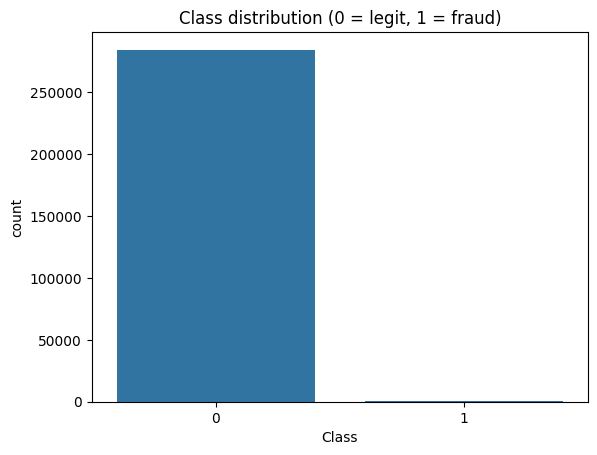

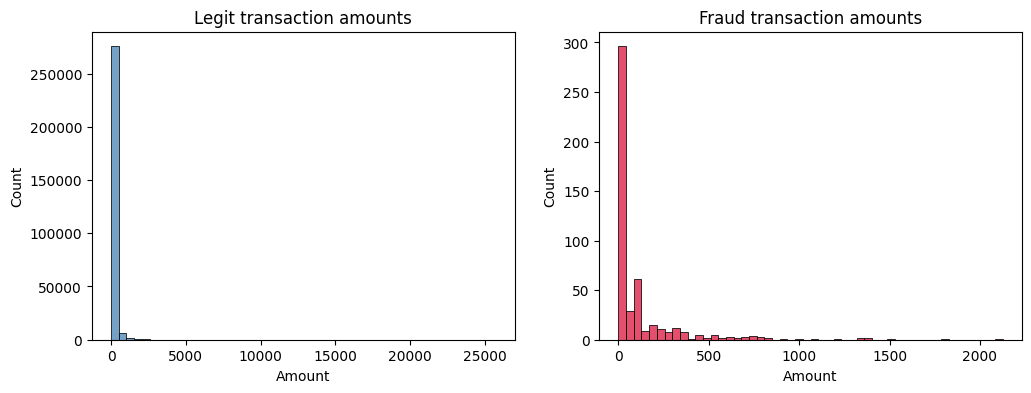

In [3]:
print(df['Class'].value_counts(normalize=True) * 100)

sns.countplot(x='Class', data=df)
plt.title("Class distribution (0 = legit, 1 = fraud)")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[df.Class == 0]['Amount'], bins=50, ax=ax[0], color='steelblue')
ax[0].set_title("Legit transaction amounts")
sns.histplot(df[df.Class == 1]['Amount'], bins=50, ax=ax[1], color='crimson')
ax[1].set_title("Fraud transaction amounts")
plt.show()

In [4]:
df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount']])
df['Time_scaled'] = StandardScaler().fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 1: SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training distribution:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

# 2: Class weighting
# scale_pos_weight for XGBoost = (count of negative class) / (count of positive class)
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f"\nscale_pos_weight for class-weighted models: {scale_pos_weight:.1f}")

Original training distribution: {0: 227451, 1: 394}
After SMOTE: {0: 227451, 1: 227451}

scale_pos_weight for class-weighted models: 577.3


In [16]:
pr_curves = {}  # store (recall, precision, label)

def evaluate(name, model, X_test, y_test, proba):
    auc_pr = average_precision_score(y_test, proba)
    auc_roc = roc_auc_score(y_test, proba)
    print(f"\n=== {name} ===")
    print(f"AUC-PR: {auc_pr:.4f} | AUC-ROC: {auc_roc:.4f}")
    print(classification_report(y_test, model.predict(X_test), digits=4))

    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_curves[name] = (recall, precision, auc_pr)
    return auc_pr, auc_roc

results = {}

In [19]:
# SMOTE version
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
proba = lr_smote.predict_proba(X_test)[:, 1]
results['LR (SMOTE)'] = evaluate("LR (SMOTE)", lr_smote, X_test, y_test, proba)

# Class-weighted version, trained on original (unbalanced) data
lr_weighted = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_weighted.fit(X_train, y_train)
proba = lr_weighted.predict_proba(X_test)[:, 1]
results['LR (class_weight)'] = evaluate("LR (class_weight)", lr_weighted, X_test, y_test, proba)


=== LR (SMOTE) ===
AUC-PR: 0.7249 | AUC-ROC: 0.9698
              precision    recall  f1-score   support

           0     0.9999    0.9744    0.9869     56864
           1     0.0581    0.9184    0.1094        98

    accuracy                         0.9743     56962
   macro avg     0.5290    0.9464    0.5481     56962
weighted avg     0.9982    0.9743    0.9854     56962


=== LR (class_weight) ===
AUC-PR: 0.7189 | AUC-ROC: 0.9722
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0609    0.9184    0.1141        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5509     56962
weighted avg     0.9982    0.9755    0.9861     56962



In [20]:
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
proba = rf_smote.predict_proba(X_test)[:, 1]
results['RF (SMOTE)'] = evaluate("RF (SMOTE)", rf_smote, X_test, y_test, proba)

rf_weighted = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1,
                                      class_weight='balanced', random_state=42)
rf_weighted.fit(X_train, y_train)
proba = rf_weighted.predict_proba(X_test)[:, 1]
results['RF (class_weight)'] = evaluate("RF (class_weight)", rf_weighted, X_test, y_test, proba)


=== RF (SMOTE) ===
AUC-PR: 0.8160 | AUC-ROC: 0.9800
              precision    recall  f1-score   support

           0     0.9998    0.9988    0.9993     56864
           1     0.5419    0.8571    0.6640        98

    accuracy                         0.9985     56962
   macro avg     0.7708    0.9279    0.8316     56962
weighted avg     0.9990    0.9985    0.9987     56962


=== RF (class_weight) ===
AUC-PR: 0.8262 | AUC-ROC: 0.9805
              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8333    0.8163    0.8247        98

    accuracy                         0.9994     56962
   macro avg     0.9165    0.9080    0.9122     56962
weighted avg     0.9994    0.9994    0.9994     56962



In [21]:
xgb_smote = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='aucpr', random_state=42
)
xgb_smote.fit(X_train_smote, y_train_smote)
proba = xgb_smote.predict_proba(X_test)[:, 1]
results['XGB (SMOTE)'] = evaluate("XGB (SMOTE)", xgb_smote, X_test, y_test, proba)

xgb_weighted = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric='aucpr', scale_pos_weight=scale_pos_weight, random_state=42
)
xgb_weighted.fit(X_train, y_train)
proba = xgb_weighted.predict_proba(X_test)[:, 1]
results['XGB (class_weight)'] = evaluate("XGB (class_weight)", xgb_weighted, X_test, y_test, proba)


=== XGB (SMOTE) ===
AUC-PR: 0.8719 | AUC-ROC: 0.9810
              precision    recall  f1-score   support

           0     0.9998    0.9994    0.9996     56864
           1     0.7227    0.8776    0.7926        98

    accuracy                         0.9992     56962
   macro avg     0.8612    0.9385    0.8961     56962
weighted avg     0.9993    0.9992    0.9992     56962


=== XGB (class_weight) ===
AUC-PR: 0.8876 | AUC-ROC: 0.9707
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8925    0.8469    0.8691        98

    accuracy                         0.9996     56962
   macro avg     0.9461    0.9234    0.9344     56962
weighted avg     0.9996    0.9996    0.9996     56962



In [22]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers

mlp = Sequential([
    layers.Input(shape=(X_train_smote.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

mlp.fit(X_train_smote, y_train_smote, epochs=10, batch_size=512,
        validation_split=0.1, verbose=1)

proba_mlp = mlp.predict(X_test).ravel()

class MLPWrapper:
    def predict(self, X):
        return (mlp.predict(X).ravel() > 0.5).astype(int)

results['MLP (SMOTE)'] = evaluate("MLP (SMOTE)", MLPWrapper(), X_test, y_test, proba_mlp)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9326 - loss: 0.1830 - val_accuracy: 0.9581 - val_loss: 0.0913
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9730 - loss: 0.0692 - val_accuracy: 0.9856 - val_loss: 0.0511
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9827 - loss: 0.0479 - val_accuracy: 0.9930 - val_loss: 0.0290
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9881 - loss: 0.0345 - val_accuracy: 0.9981 - val_loss: 0.0167
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9917 - loss: 0.0262 - val_accuracy: 0.9993 - val_loss: 0.0133
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9937 - loss: 0.0212 - val_accuracy: 1.0000 - val_loss: 0.0092
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9949 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0083
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9958 - loss: 0.0152 - val_accuracy: 1.

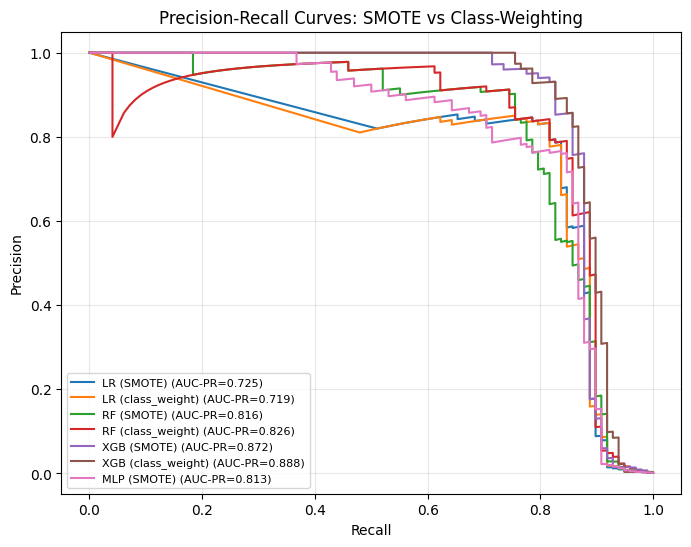

                      AUC-PR   AUC-ROC
XGB (class_weight)  0.887584  0.970706
XGB (SMOTE)         0.871896  0.981022
RF (class_weight)   0.826199  0.980532
RF (SMOTE)          0.815964  0.979954
MLP (SMOTE)         0.813166  0.969751
LR (SMOTE)          0.724861  0.969848
LR (class_weight)   0.718946  0.972167


In [23]:
plt.figure(figsize=(8, 6))
for name, (recall, precision, auc_pr) in pr_curves.items():
    plt.plot(recall, precision, label=f"{name} (AUC-PR={auc_pr:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves: SMOTE vs Class-Weighting")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.show()

summary = pd.DataFrame(results, index=['AUC-PR', 'AUC-ROC']).T
print(summary.sort_values('AUC-PR', ascending=False))

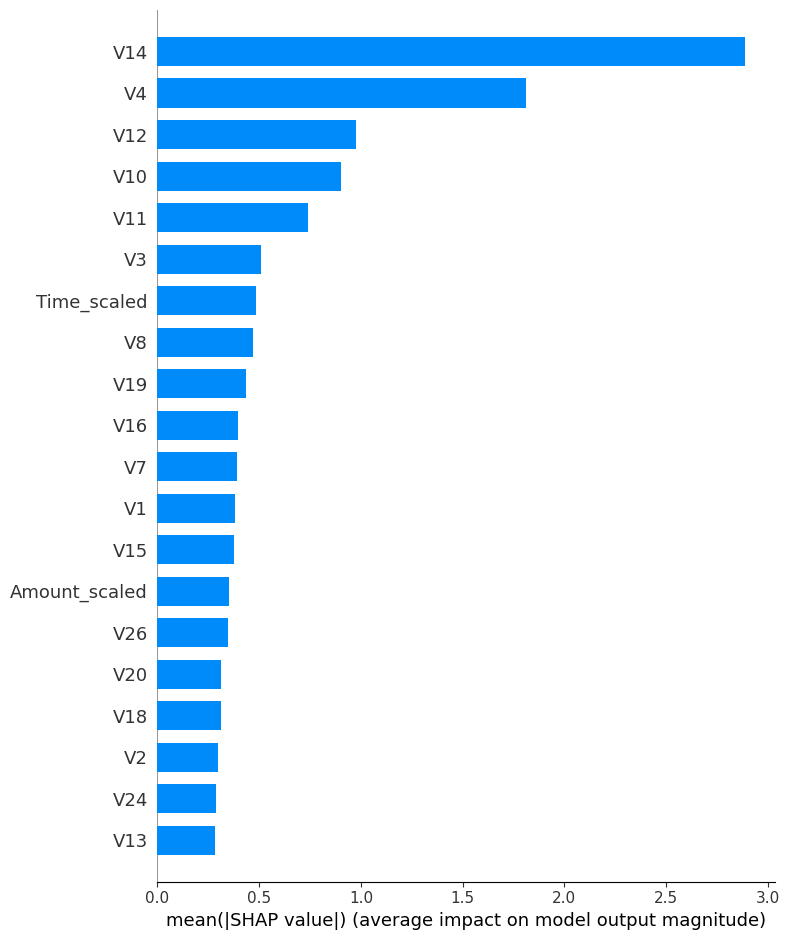

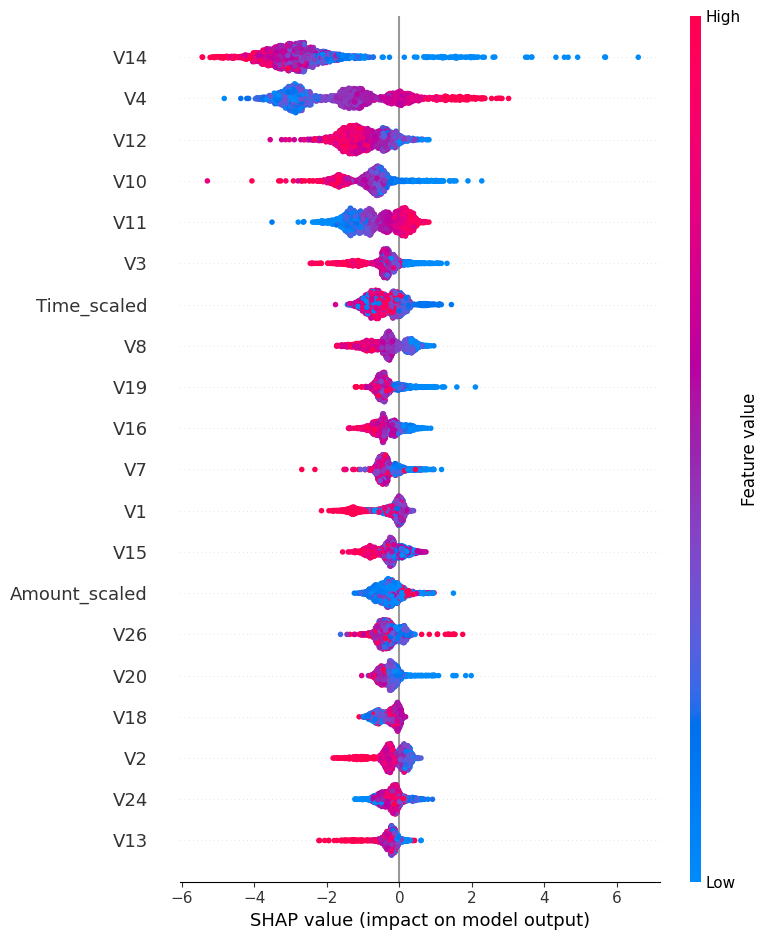

In [24]:
best_xgb = xgb_weighted if results['XGB (class_weight)'][0] > results['XGB (SMOTE)'][0] else xgb_smote

explainer = shap.TreeExplainer(best_xgb)
sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type="bar")
shap.summary_plot(shap_values, sample)